Assignment-4: Support Vector Machine (SVM)


Import required libraries


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Libraries imported')


Libraries imported


load dataset

In [12]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.rename(columns={'target':'class'}, inplace=True)
df['class'] = df['class'].apply(lambda i: iris.target_names[i])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [13]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


selecting features for visualization

In [14]:
X = df[['petal length (cm)','petal width (cm)']]
y = df['class']
X.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


train–test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)


Training size: (105, 2)
Testing size: (45, 2)


Building the SVM model

In [16]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
print('Model trained')

Model trained


predict

In [17]:
y_pred = svm.predict(X_test)
list(y_pred)[:10]

[np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor')]

Compare predictions

In [18]:
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
results['Status'] = results.apply(lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1)
results.head(20)

,Actual,Predicted,Status
0,versicolor,versicolor,Correct
1,setosa,setosa,Correct
2,virginica,virginica,Correct
3,versicolor,versicolor,Correct
4,versicolor,versicolor,Correct
5,setosa,setosa,Correct
6,versicolor,versicolor,Correct
7,virginica,virginica,Correct
8,versicolor,versicolor,Correct
9,versicolor,versicolor,Correct


Model evaluation


In [19]:

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



visualize

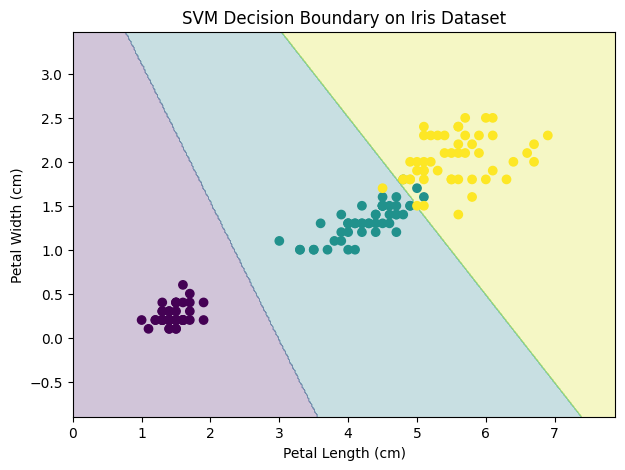

In [21]:
x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
y_min, y_max = X.iloc[:,1].min()-1, X.iloc[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Create a DataFrame for prediction to address the UserWarning and maintain feature names
X_pred_input = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns)

# Predict class labels, which will be strings
Z_str = svm.predict(X_pred_input)

# Map string labels to numerical values for plotting
# The svm.classes_ attribute holds the unique class labels encountered during fit
label_to_int = {label: i for i, label in enumerate(svm.classes_)}
Z = np.array([label_to_int[s] for s in Z_str]) # Convert string array Z_str to numerical array Z

Z = Z.reshape(xx.shape)
plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.25)
# Map original y labels to integers for consistent coloring in the scatter plot
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=[label_to_int[l] for l in y], cmap='viridis')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('SVM Decision Boundary on Iris Dataset')
plt.show()